### Quadratic Trough test case

</b> Author:   </b>  Sam MacKay

In [1]:
import sys
import jax_init

import os

#top_level_path = resolve_path(str(os.path.dirname(os.path.realpath(__file__))) + "/../")
top_level_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
print("Setting top level path for imports:", top_level_path)

# Ensure top-level path is in sys.path
if top_level_path not in sys.path:
    # makes sure top level directory path is present in system so that relative imports work
    sys.path.insert(0, top_level_path)

# if enable_x64 is set in jax_init, will have to set manually in slimline too
import slimline as solver

import importlib
importlib.reload(solver)

import numpy as np
import matplotlib.pyplot as plt


Disabling python multi-threading...
Initialising jax...

Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15), CpuDevice(id=16), CpuDevice(id=17), CpuDevice(id=18), CpuDevice(id=19), CpuDevice(id=20), CpuDevice(id=21), CpuDevice(id=22), CpuDevice(id=23), CpuDevice(id=24), CpuDevice(id=25), CpuDevice(id=26), CpuDevice(id=27), CpuDevice(id=28), CpuDevice(id=29), CpuDevice(id=30), CpuDevice(id=31)]
Setting top level path for imports: c:\Users\samma\programming\synthPy\src


Predicted size in memory of domain: 3.814697265625 MB

Memory prior to domain creation:
 - total : 31.103015899658203 GB
 - free  : 16.883167266845703 GB
 - used  : 14.2198486328125 GB

Est. domain memory limit: 8.392333984375 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (100, 100, 100) --> no padding required.

Generating test Generating field for the Quadratic Trough test case...


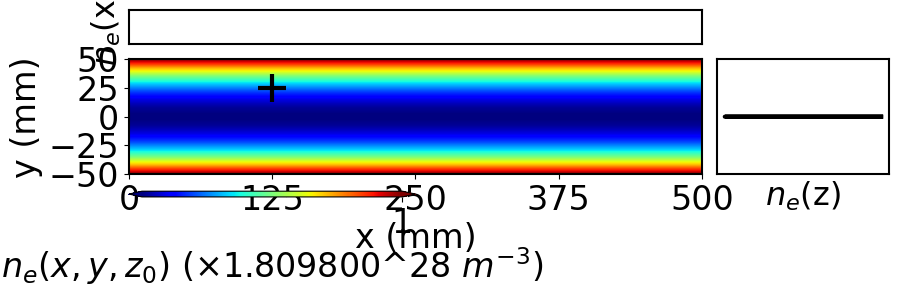

In [2]:
# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
extent_x = 50e-2
extent_y = 5e-2
extent_z = 10e-3

n_cells = 100

beam_offset = (125e-3, 25e-3, 0)
probing_extent = extent_x - beam_offset[0]
probing_direction = 'x'

#quad_trough_test
domain = solver.ScalarDomain( np.array([extent_x, 2 * extent_y, extent_z]), n_cells,
    ne_type = "quad_trough_test",
    probing_direction = probing_direction,
    zeropoint = (0, -extent_y, 0)
)

import processing.plotting as plots
importlib.reload(plots)

#plots.graph_domain(domain, slice="x", mark = beam_offset)
#plots.graph_domain(domain, slice="y", mark = beam_offset)
plots.graph_domain(domain, slice="z", mark = beam_offset)

#print(domain.ne[:, 0, :])
#print(domain.ne[:, -1, :])

#print(domain.ne.shape[1])
#print(domain.ne[:, int(domain.ne.shape[1] / 2), :])

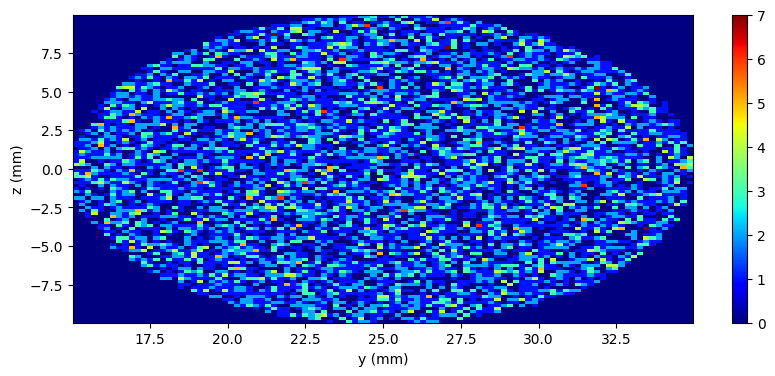

In [3]:
# initialise beam
Np = 10000    # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = extent_z    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'circular'

beam_definition = solver.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type,
    offset = beam_offset
)

from processing.plotting import inital_ray_plot
inital_ray_plot(beam_definition.s0, n_cells, slice=probing_direction)

In [4]:
#output timestepped saved values
# do analysis

#rf, duration = solver.solve(beam_definition.s0, domain, probing_extent)

# 1e-4, 1e-8 is the highest accuracy that is feasible to calculate on my device
solutions, duration = solver.solve(beam_definition.s0, domain, probing_extent, save_points_per_region = 128, return_raw_results = True, rtol = 1e-3, atol = 1e-6, lwl = 351e-9)


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 8.0108642578125 MB
 --> Np = 10000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.375 mm's to the target depth of 0.375 mm's

Running device: cpu, with: 32 cores.
NamedSharding(mesh=Mesh('rows': 32, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=device)

Completed ray trace in 9.176 seconds.



There are 128 data points available to plot per ray.


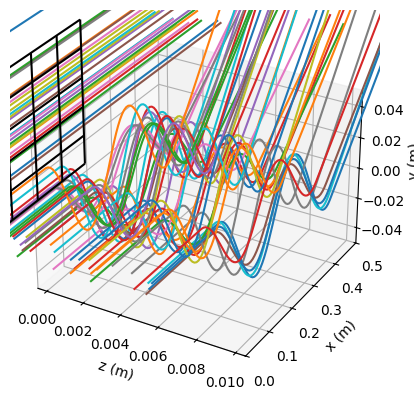

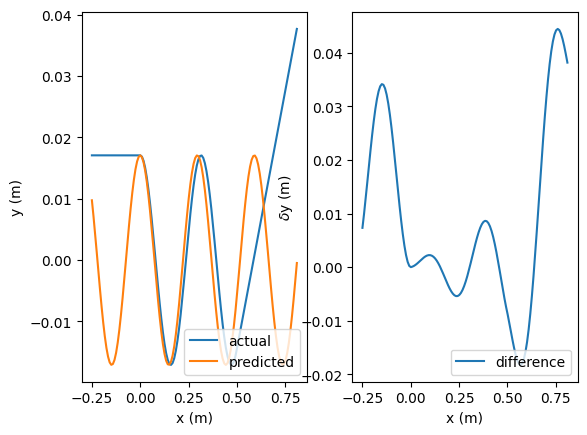

In [5]:
#%matplotlib qt
from processing.plotting import stepped_ray_plot
stepped_ray_plot(solutions, domain, sample_size = 64)

#def analytical_y(x, y_0 = 25e-3, y_c = 5e-2):
#    #y_0 = y_0[:, None]
#    y_0 = np.expand_dims(y_0, axis=1)
#    return y_0[:, 0] * np.cos(x[:, :] / np.sqrt(y_c ** 2 - y_0[:, 0] ** 2))

def analytical_y(x, y_0, y_c = 5e-2):
    """
    x   : array of shape [N, M]
    y_0 : array of shape [N]
    """
    y_0 = np.asarray(y_0)[:, None]        # -> [N, 1]
    denom = np.sqrt(y_c**2 - y_0**2)       # -> [N, 1]
    return y_0 * np.cos(x / denom)         # -> [N, M]

x = solutions[0].ys[:, :, 0]
y = solutions[0].ys[:, :, 1]
z = solutions[0].ys[:, :, 2]

y_pred = analytical_y(x, y_0 = y[:, 0])
delta = y - y_pred

index = 0
curr_mag = 0
for position, array_to_check in enumerate(delta):
    for val in array_to_check:
        curr_mag += val**2
    curr_mag = np.sqrt(curr_mag)
    if position == 0:
        mag = curr_mag

    if mag > curr_mag:
        index = position

index = 55
x = x[index, :]
y = y[index, :]
z = z[index, :]
y_pred = y_pred[index, :]
delta = delta[index, :]

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(x, y, label = 'actual')
ax1.plot(x, y_pred, label = 'predicted')

ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')

ax2.plot(x, delta, label = 'difference')

ax2.set_xlabel('x (m)')
ax2.set_ylabel(r'$\delta$' + 'y (m)')

ax1.legend(loc="lower right")
ax2.legend(loc="lower right")

plt.show()

In [6]:
#from processing.plotting import general_ray_plots
#general_ray_plots(rf, n_cells, lwl = lwl, ignore_lens = True)

In [7]:
#refractometer = solver.Refractometry(lwl, rf)
#refractometer.plot_rays(bin_scale = 1, clear_mem = True)

#plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))
#plt.show()